# 权重衰退

In [1]:
import torch
from torch import nn
from d2l import torch as d2l
%matplotlib inline

$y = 0.05 + \sum_{i=1}^{d} 0.01 x_i + \varepsilon \quad \text{where } \varepsilon \sim \mathcal{N}(0, 0.01^2)$
这里生成一些数据集

In [2]:
n_train,n_test,num_inputs,batch_size = 20,100,200,5
true_w,true_b = torch.ones((num_inputs,1))*0.01,0.05
train_data = d2l.synthetic_data(true_w,true_b,n_train)
train_iter = d2l.load_array(train_data,batch_size)
test_data = d2l.synthetic_data(true_w,true_b,n_test)
test_iter = d2l.load_array(test_data,batch_size,is_train=False)


In [3]:
def init_params():
    w=torch.normal(0,1,size=(num_inputs,1),requires_grad=True)
    b=torch.zeros(1,requires_grad=True)
    return [w,b]

In [20]:
def L2_penalty(w):
    return torch.sum(w.pow(2))/2

def L1_penalty(w):
    return torch.sum(torch.abs(w))

In [21]:
def train(lambd):
    w,b=init_params()
    net,loss =lambda X: d2l.linreg(X,w,b),d2l.squared_loss
    num_epochs,lr=100,0.03
    animator=d2l.Animator(xlabel='epoch',ylabel='loss',yscale='log',xlim=[5,num_epochs],legend=['train','test'])

    for epoch in range(num_epochs):
        for X,y in train_iter:
            l=loss(net(X),y)+lambd*L2_penalty(w)
            l.sum().backward()
            d2l.sgd([w,b],lr,batch_size)
        if (epoch+1)%5==0:
            animator.add(epoch+1,(d2l.evaluate_loss(net,train_iter,loss),d2l.evaluate_loss(net,test_iter,loss)))
    print(f'w的L2范数是：{torch.norm(w).item():.4f}')   

def train_l1(lambd):
    w,b=init_params()
    net,loss =lambda X: d2l.linreg(X,w,b),d2l.squared_loss
    num_epochs,lr=100,0.03
    animator=d2l.Animator(xlabel='epoch',ylabel='loss',yscale='log',xlim=[5,num_epochs],legend=['train','test'])

    for epoch in range(num_epochs):
        for X,y in train_iter:
            l=loss(net(X),y)+lambd*L1_penalty(w)
            l.sum().backward()
            d2l.sgd([w,b],lr,batch_size)
        if (epoch+1)%5==0:
            animator.add(epoch+1,(d2l.evaluate_loss(net,train_iter,loss),d2l.evaluate_loss(net,test_iter,loss)))
    print(f'w的L1范数是：{torch.norm(w, p=1).item():.4f}') 

w的L1范数是：146.4918


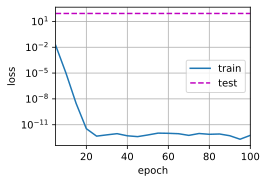

In [22]:
#train(lambd=0)  # 没有权重衰减   
"""这里是非常明显的而过拟合"""
train_l1(lambd=0)  # 没有权重衰减

w的L1范数是：9.3599


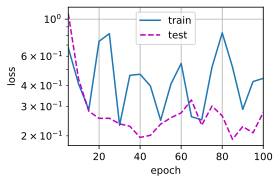

In [23]:
#train(lambd=3) 
train_l1(lambd=3)  # 有权重衰减

w的L1范数是：95.9133


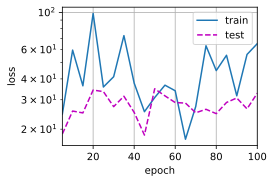

In [24]:
#train(lambd=30)
train_l1(lambd=30)  # 有权重衰减

# 简洁实现

In [15]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())

w的L2范数： 13.04987907409668


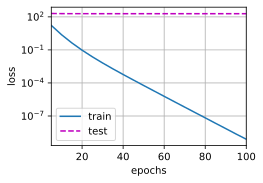

In [16]:
train_concise(0)

w的L2范数： 0.6048624515533447


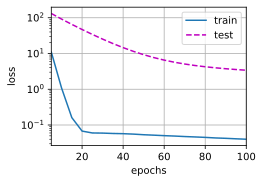

In [17]:
train_concise(3)

w的L2范数： 0.0451199971139431


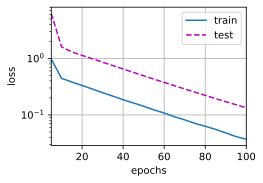

In [18]:
train_concise(30)